In [5]:
# Cell 1
import sys
sys.path.append(".")

from pathlib import Path
import pandas as pd
import geopandas as gpd

from preprocessing_utils import (
    AOIAcquirer, LocalRiverLoader, AOITiler, VectorCleaner,
    TileExporter, TileFuser, processed_tile_ids, apply_buffer_filter,
    AOI_PATH, RIVER_SHAPEFILE_PATH, RIVER_PATH, TRAINING_CSV_PATH, TILE_DIR,TILE_SIZE_M,
)

Dropped 3 degenerate geometries
River segments loaded: 428


<Axes: >

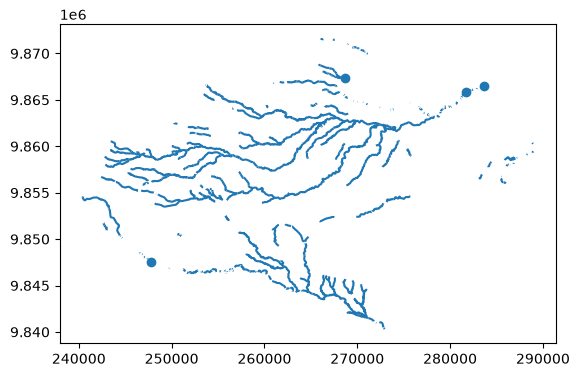

In [2]:
# Cell 2
aoi_acquirer = AOIAcquirer(place_name="Nairobi, Kenya")
aoi_wgs84, aoi_metric = aoi_acquirer.acquire()
aoi_acquirer.save(aoi_metric, str(AOI_PATH))

river_loader = LocalRiverLoader(str(RIVER_SHAPEFILE_PATH))
river = river_loader.load(aoi_metric)
river_loader.save(river, str(RIVER_PATH))
river_lines_only = river[river.geometry.length > 1]  # drop zero/near-zero-length artifacts
print(f"Dropped {len(river) - len(river_lines_only)} degenerate geometries")
river_union = river_lines_only.geometry.union_all()

print(f"River segments loaded: {len(river)}")
river.plot()

In [6]:
# Cell 3
# tiler = AOITiler(tile_size_m=5000)
# tiles = tiler.generate_tiles(aoi_metric)
# print(f"Generated {len(tiles)} tiles")

# exporter = TileExporter(gdrive_folder="EarthEngine")
# manifests = []
# for i, tile_box in enumerate(tiles):
#     print(f"Submitting exports for tile {i + 1}/{len(tiles)}")
#     manifest = exporter.export_tile(tile_index=i, tile_box=tile_box)
#     manifests.append(manifest)

# print("\nDownload these files from Drive's 'EarthEngine' folder into data/raw/tiles/:")
# for m in manifests:
#     print(" ", m["buildings_filename"])
#     print(" ", m["raster_filename"])

# Cell 3 (replacement) — rebuild manifests from what's already downloaded,
# no new GEE exports submitted
# Load the exact same AOI that was used to generate the original 48 tiles
aoi_metric = gpd.read_file(AOI_PATH)

tiler = AOITiler(tile_size_m=TILE_SIZE_M)
tiles = tiler.generate_tiles(aoi_metric)
print(f"Regenerated {len(tiles)} tiles")  # should print 48 — if it doesn't, stop and check AOI_PATH

manifests = []
for i in range(len(tiles)):
    manifests.append({
        "tile_index": i,
        "buildings_filename": f"nairobi_buildings_tile_{i}.geojson",
        "raster_filename": f"nairobi_sentinel_tile_{i}.tif",
    })

Regenerated 48 tiles


In [7]:
# Cell 4
cleaner = VectorCleaner()
fuser = TileFuser(river_union=river_union, cleaner=cleaner, tile_dir=TILE_DIR)

csv_path = Path(TRAINING_CSV_PATH)
already_done = processed_tile_ids(csv_path)
print(f"Tiles already in CSV: {sorted(already_done)}")

for manifest in manifests:
    tile_id = manifest["tile_index"]
    if tile_id in already_done:
        continue
    if not fuser.files_ready(manifest):
        print(f"Tile {tile_id}: files not downloaded yet, skipping for now.")
        continue

    tile_df = fuser.fuse(manifest)
    write_header = not csv_path.exists()
    tile_df.to_csv(csv_path, mode="a", header=write_header, index=False)
    print(f"Tile {tile_id}: appended {len(tile_df):,} rows")

print("Done with this pass. Re-run this cell after downloading more files.")

Tiles already in CSV: []
Tile 0: appended 251,502 rows
Tile 1: appended 251,502 rows
Tile 2: appended 251,502 rows
Tile 3: appended 251,502 rows
Tile 4: appended 251,502 rows
Tile 5: appended 251,502 rows
Tile 6: appended 251,502 rows
Tile 7: appended 251,502 rows
Tile 8: appended 251,502 rows
Tile 9: appended 251,502 rows
Tile 10: appended 251,502 rows
Tile 11: appended 251,502 rows
Tile 12: appended 251,001 rows
Tile 13: appended 251,502 rows
Tile 14: appended 251,502 rows
Tile 15: appended 251,502 rows
Tile 16: appended 251,001 rows
Tile 17: appended 251,001 rows
Tile 18: appended 251,502 rows
Tile 19: appended 251,502 rows
Tile 20: appended 251,502 rows
Tile 21: appended 251,502 rows
Tile 22: appended 251,001 rows
Tile 23: appended 251,001 rows
Tile 24: appended 251,001 rows
Tile 25: appended 251,502 rows
Tile 26: appended 251,502 rows
Tile 27: appended 251,502 rows
Tile 28: appended 251,001 rows
Tile 29: appended 251,001 rows
Tile 30: appended 251,001 rows
Tile 31: appended 251,00

In [8]:
# Cell 5
training_df = pd.read_csv(TRAINING_CSV_PATH)
print(training_df.shape)
print(training_df["built_up"].value_counts(normalize=True))

preview_30m = apply_buffer_filter(training_df, buffer_meters=30)
preview_60m = apply_buffer_filter(training_df, buffer_meters=60)
print("Pixels inside 30m buffer:", preview_30m["inside_buffer"].sum())
print("Pixels inside 60m buffer:", preview_60m["inside_buffer"].sum())

(12060072, 12)
built_up
0    0.921861
1    0.078139
Name: proportion, dtype: float64
Pixels inside 30m buffer: 213962
Pixels inside 60m buffer: 429130


In [9]:
riparian_30m = apply_buffer_filter(training_df, buffer_meters=30)
riparian_30m = riparian_30m[riparian_30m["inside_buffer"]]

print(riparian_30m["built_up"].value_counts(normalize=True))

built_up
0    0.936479
1    0.063521
Name: proportion, dtype: float64


In [10]:
encroaching_30m = riparian_30m[riparian_30m["built_up"] == 1]
print(f"Encroaching pixels (30m buffer): {len(encroaching_30m):,}")

Encroaching pixels (30m buffer): 13,591


In [11]:
dupes = training_df.duplicated(subset=["x", "y"]).sum()
print(f"Duplicate pixel coordinates: {dupes:,}")

Duplicate pixel coordinates: 50,071


In [14]:
training_df = training_df.drop_duplicates(subset=["x", "y"])

In [16]:
training_df.shape

(12010001, 12)

In [15]:
for band in ["B4", "B3", "B2", "B8"]:
    print(band, training_df[band].describe())

B4 count    1.199874e+07
mean     1.042227e+03
std      4.233196e+02
min      1.270000e+02
25%      7.490000e+02
50%      1.046000e+03
75%      1.305000e+03
max      8.752000e+03
Name: B4, dtype: float64
B3 count    1.199874e+07
mean     9.049645e+02
std      3.078731e+02
min      1.880000e+02
25%      7.080000e+02
50%      8.780000e+02
75%      1.053000e+03
max      8.160000e+03
Name: B3, dtype: float64
B2 count    1.199874e+07
mean     6.801184e+02
std      2.995656e+02
min      1.380000e+02
25%      4.710000e+02
50%      6.540000e+02
75%      8.210000e+02
max      7.984000e+03
Name: B2, dtype: float64
B8 count    1.199874e+07
mean     2.360164e+03
std      4.861760e+02
min      1.820000e+02
25%      2.070000e+03
50%      2.316000e+03
75%      2.614000e+03
max      8.312000e+03
Name: B8, dtype: float64


In [18]:
# Which tile has the most existing built_up pixels — likely a dense area
tile_built_counts = training_df[training_df["built_up"] == 1]["tile_id"].value_counts()
print(tile_built_counts.head(10))

tile_id
21    59750
15    56058
29    50765
28    50061
6     47483
10    47107
30    42656
22    40674
20    34392
38    28669
Name: count, dtype: int64


In [20]:
dense_tile_id = tile_built_counts.index[0]  # or manually pick a tile you know covers Kibera/Mathare
dense_manifest = manifests[dense_tile_id]

old_count = training_df[
    (training_df["tile_id"] == dense_tile_id) & (training_df["built_up"] == 1)
].shape[0]

new_tile_df = fuser.fuse(dense_manifest)
new_count = (new_tile_df["built_up"] == 1).sum()

print(f"Tile {dense_tile_id} built-up pixels — before: {old_count:,}, after: {new_count:,}")

Tile 21 built-up pixels — before: 59,750, after: 60,249


In [23]:
# Cell 6 — Cleaning: NaNs, duplicates, and reflectance sanity check

print("Before cleaning:", training_df.shape)

# 1. Drop rows with NaN in any spectral band (missed by the nodata filter,
#    which only catches all-zero rows, not NaN rows)
training_df = training_df.dropna(subset=["B4", "B3", "B2", "B8"])
print("After dropping NaN bands:", training_df.shape)

# 2. Drop duplicate pixel coordinates (tile-edge overlap) — reassigned this time
training_df = training_df.drop_duplicates(subset=["x", "y"])
print("After dropping duplicates:", training_df.shape)

# 3. Reflectance sanity check — Sentinel-2 SR values shouldn't be negative
#    or absurdly high; flag rather than silently drop, so you can decide
for band in ["B4", "B3", "B2", "B8"]:
    negative = (training_df[band] < 0).sum()
    extreme = (training_df[band] > 10000).sum()  # SR reflectance rarely exceeds this
    if negative or extreme:
        print(f"{band}: {negative:,} negative values, {extreme:,} values > 10000")

print("\nFinal shape after cleaning:", training_df.shape)
print(training_df["built_up"].value_counts(normalize=True))

Before cleaning: (12010001, 12)
After dropping NaN bands: (11998745, 12)
After dropping duplicates: (11998745, 12)

Final shape after cleaning: (11998745, 12)
built_up
0    0.921908
1    0.078092
Name: proportion, dtype: float64


In [24]:
# Reflectance sanity check — haven't seen this output yet
for band in ["B4", "B3", "B2", "B8"]:
    negative = (training_df[band] < 0).sum()
    extreme = (training_df[band] > 10000).sum()
    if negative or extreme:
        print(f"{band}: {negative:,} negative values, {extreme:,} values > 10000")
    else:
        print(f"{band}: no negative or extreme values")

B4: no negative or extreme values
B3: no negative or extreme values
B2: no negative or extreme values
B8: no negative or extreme values


In [25]:
CLEANED_CSV_PATH = TRAINING_CSV_PATH.parent / "nairobi_training_pixels_clean.csv"
training_df.to_csv(CLEANED_CSV_PATH, index=False)
print(f"Saved: {CLEANED_CSV_PATH} ({len(training_df):,} rows)")

Saved: ..\data\output\nairobi_training_pixels_clean.csv (11,998,745 rows)
